## Ano

In [1]:
# import pandas as pd
# df_list = []

# for year in range(2019,2025):
#     if year == 2019:
#         df_list.append(pd.read_parquet(f"../../data/02_clean/returns_{year-9}_{year}.parquet"))
#     else:
#         df_list.append(pd.read_parquet(f"../../data/02_clean/returns_{year}.parquet"))

In [2]:
# df = pd.concat(df_list)

# for year in range(2019,2025):
#     df.loc[str(year - 1):str(year)].to_parquet(f"../../data/02_clean/returns_{year-1}_{year}.parquet")

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.covariance import LedoitWolf
import seaborn as sns
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
from tqdm import tqdm
import pickle
from functions import (
    corr_matrix, get_network_TMFG, build_and_save_graph
)

years = range(2019,2025)

# modes = {}

# for year in years:
#     modes[f"fast_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/fast_emd.parquet")
#     modes[f"medium_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/medium_emd.parquet")
#     modes[f"slow_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/slow_emd.parquet")

returns = {}

for year in years:
    returns[year] = pd.read_parquet(f"../../data/02_clean/returns_{year-9}_{year}.parquet")
    returns[year] = np.log(1 + returns[year])
    
    # Drop columns with ALL NaNs upfront
    returns[year] = returns[year].dropna(axis=1, how='all')
    returns[year].drop(columns=["ABVC", "WKSP"], inplace=True)

common_cols = set(returns[years[0]].columns)
for year in years[1:]:
    common_cols &= set(returns[year].columns)

common_cols = sorted(list(common_cols))

# Apply common columns to all years
for year in years:
    original_cols = returns[year].shape[1]
    returns[year] = returns[year][common_cols]
    print(f"Year {year}: {original_cols} -> {returns[year].shape[1]} columns")

Year 2019: 404 -> 401 columns
Year 2020: 403 -> 401 columns
Year 2021: 404 -> 401 columns
Year 2022: 403 -> 401 columns
Year 2023: 404 -> 401 columns
Year 2024: 403 -> 401 columns


In [4]:
# corr = {}

# for year in years:
#     corr[f"corr_fast_{year}"] = corr_matrix(modes[f"fast_{year}"])
#     corr[f"corr_medium_{year}"] = corr_matrix(modes[f"medium_{year}"])
#     corr[f"corr_slow_{year}"] = corr_matrix(modes[f"slow_{year}"])

corr = {}

for year in years:
    corr[year] = corr_matrix(returns[year])

In [2]:
def exponential_weights(t, tau=125):
    """
    Generate exponential weights: w_t = w_0 * exp(-t/tau)
    Normalized so sum(w) = 1
    
    Parameters:
    -----------
    t : int
        Length of time window
    tau : int
        Characteristic time horizon (half-life)
    
    Returns:
    --------
    weights : array
        Exponential weights (most recent = highest weight)
    """
    # Time indices (0 = oldest, t-1 = most recent)
    time_idx = np.arange(t)
    
    # Exponential decay (recent events have higher weight)
    weights = np.exp(-time_idx / tau)
    weights = weights / weights.sum()  # Normalize
    
    # Reverse so most recent has highest weight
    return weights[::-1]

def weighted_correlation(returns, weights):
    """
    Compute weighted Pearson correlation matrix.
    
    Parameters:
    -----------
    returns : DataFrame
        Returns data (rows=time, columns=stocks)
    weights : array
        Time weights (same length as returns)
    
    Returns:
    --------
    corr_matrix : DataFrame
        Weighted correlation matrix
    """
    # Weighted mean
    weighted_mean = (returns * weights[:, None]).sum(axis=0)
    
    # Center the data
    centered = returns - weighted_mean
    
    # Weighted covariance
    weighted_cov = (centered.T @ (centered * weights[:, None])) / weights.sum()
    
    # Convert to correlation
    std = np.sqrt(np.diag(weighted_cov))
    corr = weighted_cov / np.outer(std, std)
    
    return pd.DataFrame(corr, index=returns.columns, columns=returns.columns)


def shrinkage_correlation(corr_matrices):
    """
    Apply shrinkage to average correlation matrix (Eq. 1 from paper).
    
    Averages correlation matrices over time window and shrinks toward
    the grand mean correlation.
    
    Parameters:
    -----------
    corr_matrices : list of DataFrames
        List of correlation matrices over time window
    
    Returns:
    --------
    shrunk_corr : DataFrame
        Shrinkage-adjusted correlation matrix
    """
    # Average the correlation matrices
    avg_corr = sum(corr_matrices) / len(corr_matrices)
    
    # Compute grand mean correlation (off-diagonal only)
    n = len(avg_corr)
    upper_tri_indices = np.triu_indices(n, k=1)
    grand_mean = avg_corr.values[upper_tri_indices].mean()
    
    # Shrinkage formula from paper (Eq. 1)
    shrinkage_factor = 1 / (2 * (len(corr_matrices) + 1))
    
    shrunk = (1 - shrinkage_factor) * avg_corr.values + shrinkage_factor * grand_mean
    
    # Ensure diagonal = 1
    np.fill_diagonal(shrunk, 1.0)
    
    return pd.DataFrame(shrunk, index=avg_corr.index, columns=avg_corr.columns)

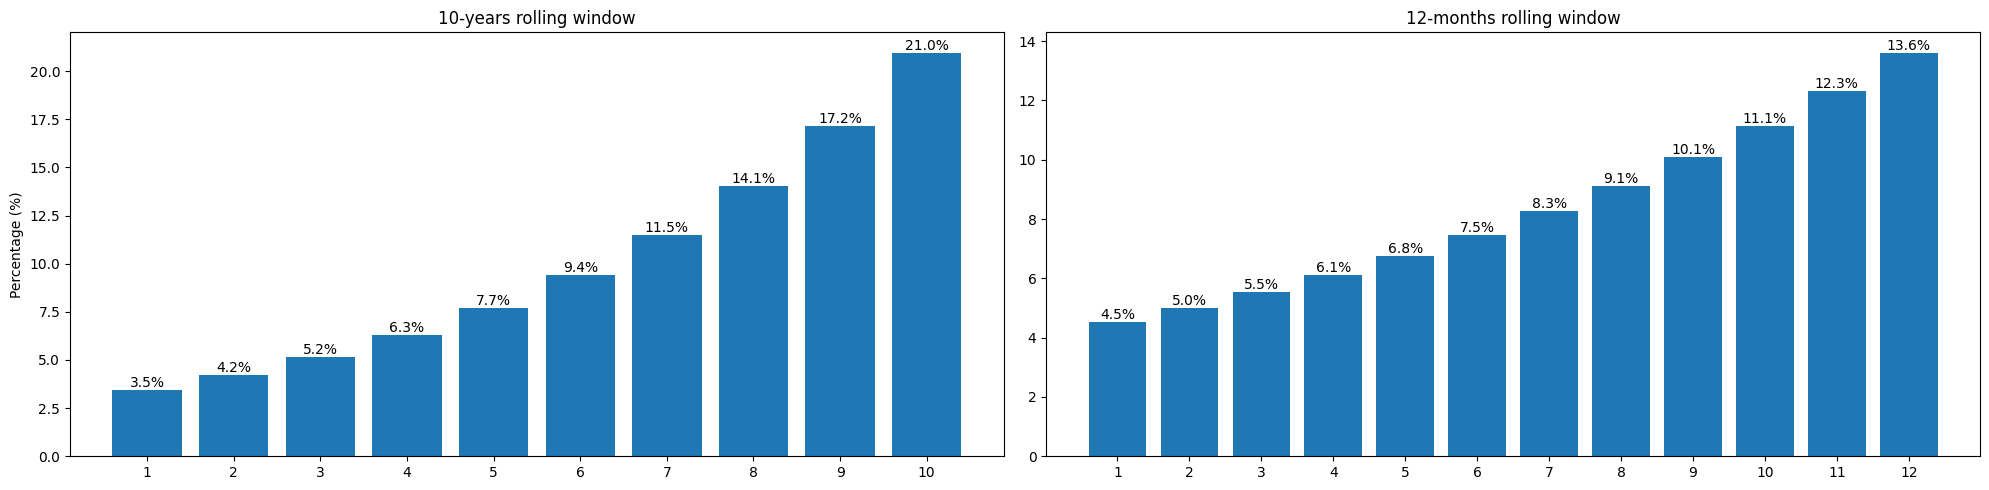

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Get weights
w1 = exponential_weights(t=10, tau=5)
w2 = exponential_weights(t=12, tau=10)

# Convert to percentages
p1 = 100 * np.array(w1) / np.sum(w1)
p2 = 100 * np.array(w2) / np.sum(w2)

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# ---- First subplot ----
bars1 = axes[0].bar(range(len(p1)), p1)
axes[0].set_title("10-years rolling window")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_xticks(ticks=range(0,10), labels=range(1,11))

for i, v in enumerate(p1):
    axes[0].text(i, v, f"{v:.1f}%", ha='center', va='bottom')

# ---- Second subplot ----
bars2 = axes[1].bar(range(len(p2)), p2)
axes[1].set_title("12-months rolling window")
axes[1].set_xticks(ticks=range(0,12), labels=range(1,13))

for i, v in enumerate(p2):
    axes[1].text(i, v, f"{v:.1f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [236]:
robust_corr = {}

for year in range(2019,2025):
    print(f"{year}")
    temp = returns[year]
    all_columns = temp.dropna(axis=1, how='all').columns

    window_days = 252
    tau = 5
    years_back = 10

    t_idx = len(temp) - 1
    t = temp.index[t_idx]

    corr_matrices_window = []

    if years_back > 1:
        window_days = 252
        tau = 5
        for k in range(years_back):
            window_end = t_idx - k * window_days
            window_start = window_end - window_days

            if window_start >= 0:
                window = temp.iloc[window_start:window_end]

                # Drop columns with ALL NaNs first!
                window_clean = window.dropna(axis=1, how='all').dropna(axis=0)

                if len(window_clean) >= window_days * 0.8:
                    corr_matrices_window.append(window_clean.corr())

        corr_matrices_window = corr_matrices_window[::-1]

        if len(corr_matrices_window) > 0:
            n = len(corr_matrices_window)
            
            # Expo weights across windows — most recent window gets highest weight
            across_weights = exponential_weights(n, tau=tau)

            weighted_avg_corr = np.sum(
                [w * C for w, C in zip(across_weights, corr_matrices_window)],
                axis=0
            )

            n = len(weighted_avg_corr)
            upper_tri_indices = np.triu_indices(n, k=1)
            grand_mean = weighted_avg_corr[upper_tri_indices].mean()

            shrinkage_factor = 1 / (2 * (len(corr_matrices_window) + 1))

            shrunk = (1 - shrinkage_factor) * weighted_avg_corr + shrinkage_factor * grand_mean

            # Ensure diagonal = 1
            np.fill_diagonal(shrunk, 1.0)

            robust_corr[year] = pd.DataFrame(shrunk, index=all_columns, columns=all_columns)
    elif years_back == 1:
        window_days = 21
        tau = 10
        for k in range(12):
            window_end = t_idx - k * window_days
            window_start = window_end - window_days

            if window_start >= 0:
                window = temp.iloc[window_start:window_end]

                # Drop columns with ALL NaNs first!
                window_clean = window.dropna(axis=1, how='all').dropna(axis=0)

                if len(window_clean) >= window_days * 0.8:
                    corr_matrices_window.append(window_clean.corr())

        corr_matrices_window = corr_matrices_window[::-1]

        if len(corr_matrices_window) > 0:
            n = len(corr_matrices_window)
            
            # Expo weights across windows — most recent window gets highest weight
            across_weights = exponential_weights(n, tau=tau)

            weighted_avg_corr = np.sum(
                [w * C for w, C in zip(across_weights, corr_matrices_window)],
                axis=0
            )

            n = len(weighted_avg_corr)
            upper_tri_indices = np.triu_indices(n, k=1)
            grand_mean = weighted_avg_corr[upper_tri_indices].mean()

            shrinkage_factor = 1 / (2 * (len(corr_matrices_window) + 1))

            shrunk = (1 - shrinkage_factor) * weighted_avg_corr + shrinkage_factor * grand_mean

            # Ensure diagonal = 1
            np.fill_diagonal(shrunk, 1.0)

            robust_corr[year] = pd.DataFrame(shrunk, index=all_columns, columns=all_columns)

2019
2020
2021
2022
2023
2024


In [238]:
graph = {}

# Lista de todas as tarefas (ano, velocidade)
tasks = [year for year in years]

# Barra de progresso
for year in tqdm(tasks, desc="Construindo grafos"):
    # Recupera a matriz de correlação (DataFrame com nomes dos ativos)
    corr_matrix = robust_corr[year]

    # Constroi o grafo TMFG
    G = get_network_TMFG(corr_matrix)

    # Cria a pasta se não existir e salva
    base_path = f"../../data/04_graphs/{year}_{years_back}"
    os.makedirs(base_path, exist_ok=True)
    file_path = os.path.join(base_path, f"graph.gpickle")
    with open(file_path, "wb") as f:
        pickle.dump(G, f)

    # Armazena no dicionário
    graph[f"graph_{year}"] = G

Construindo grafos: 100%|██████████| 6/6 [00:53<00:00,  9.00s/it]


In [239]:
len(corr_matrices_window)

9